# 1.Carga y exploración inicial datos

In [1]:
# ==============================================================
# 1.1 Importar librerías
# ==============================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [ ]:
# ==============================================================
# 1.2 Cargar dataset (ajusta la ruta)
# ==============================================================
import os
from pathlib import Path
import platform
import pandas as pd

# Detectar sistema operativo
so = platform.system()  # Devuelve 'Windows', 'Darwin' (Mac) o 'Linux'

if so == "Windows":
    project_dir = Path(r"D:\Cursos\Data_Analytics\Portfolio\Portfolio_Github\Proyecto_Airbnb")
elif so == "Darwin":  # Mac
    project_dir = Path("/Users/danielalvarezmiguez/Desktop/Portfolio-Power-Bi/Proyecto_Airbnb")
else:
    raise Exception("Sistema operativo no soportado")

# Ruta al CSV dentro de Data
csv_path = project_dir / "Data" / "listings.csv"

# Verifica que exista
print("Ruta CSV:", csv_path)
print("Existe?", csv_path.exists())

# Leer CSV
if csv_path.exists():
    df = pd.read_csv(csv_path)
else:
    raise FileNotFoundError(f"No se encontró el archivo CSV en {csv_path}")

Ruta CSV: C:\Users\Maria\Desktop\Proyecto Bootcamp\Repositorio GitHub\Proyecto_Airbnb\Data\listings.csv
Existe? True


In [3]:
# ==============================================================
# 1.3 Ver número filas y columnas
# ==============================================================
print("Dimensiones del dataset:", df.shape)



Dimensiones del dataset: (26004, 18)


In [4]:
# ==============================================================
# 1.4 Ver primeras filas
# ==============================================================
print(df.head(20).to_string())

        id                                                name  host_id       host_name    neighbourhood_group neighbourhood  latitude  longitude        room_type  price  minimum_nights  number_of_reviews last_review  reviews_per_month  calculated_host_listings_count  availability_365  number_of_reviews_ltm  license
0    21853                                Bright and airy room    83531           Abdel                 Latina      Cármenes  40.40381   -3.74130     Private room   29.0               4                 33  2018-07-15               0.25                               2               340                      0      NaN
1    30320                               Apartamentos Dana Sol   130907            Dana                 Centro           Sol  40.41476   -3.70418  Entire home/apt    NaN               5                172  2022-09-26               0.94                               3               337                      0      NaN
2    30959                     Beautiful loft 

In [5]:
# ==============================================================
# 1.5 Ver tipos de datos
# ==============================================================
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26004 entries, 0 to 26003
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              26004 non-null  int64  
 1   name                            26004 non-null  object 
 2   host_id                         26004 non-null  int64  
 3   host_name                       25989 non-null  object 
 4   neighbourhood_group             26004 non-null  object 
 5   neighbourhood                   26004 non-null  object 
 6   latitude                        26004 non-null  float64
 7   longitude                       26004 non-null  float64
 8   room_type                       26004 non-null  object 
 9   price                           20080 non-null  float64
 10  minimum_nights                  26004 non-null  int64  
 11  number_of_reviews               26004 non-null  int64  
 12  last_review                     

In [6]:
# ==============================================================
# 1.6 Ver valores nulos por columna
# ==============================================================
# Total de filas
total_filas = len(df)

# Conteo de nulos
nulos = df.isnull().sum()

# Porcentaje de nulos
porcentaje_nulos = (nulos / total_filas) * 100

# Mostrar como DataFrame ordenado
resultado = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': porcentaje_nulos.round(2)
}).sort_values(by='Porcentaje (%)', ascending=False)

print(resultado)

                                Nulos  Porcentaje (%)
license                         21608           83.09
price                            5924           22.78
reviews_per_month                5241           20.15
last_review                      5241           20.15
host_name                          15            0.06
id                                  0            0.00
name                                0            0.00
neighbourhood                       0            0.00
neighbourhood_group                 0            0.00
host_id                             0            0.00
room_type                           0            0.00
longitude                           0            0.00
latitude                            0            0.00
number_of_reviews                   0            0.00
minimum_nights                      0            0.00
calculated_host_listings_count      0            0.00
availability_365                    0            0.00
number_of_reviews_ltm       

# 2.Limpieza de datos

In [7]:
# ==============================================================
# 2.1 Precios y detección de outliers con IQR
# ==============================================================
df['price'] = df['price'].replace('[\€,]', '', regex=True).astype(float)

In [8]:
# Eliminar precios no válidos (≤ 0)
df = df[df['price'] > 0]

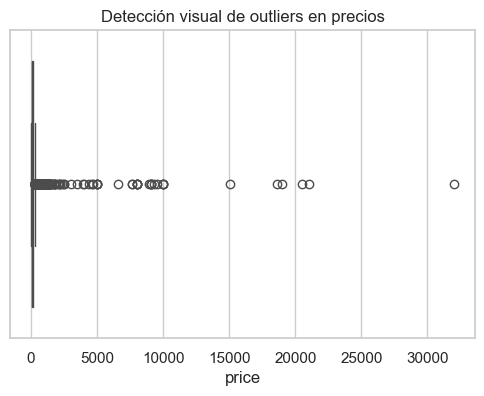

In [9]:
# Boxplot antes de limpiar
plt.figure(figsize=(6,4))
sns.boxplot(x=df['price'])
plt.title("Detección visual de outliers en precios")
plt.show()

In [10]:
# Cálculo del IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR


In [11]:
# Forzar límite inferior lógico (ningún precio <= 0)
lower_bound_logico = max(lower_bound, 1)  # ajusta según consideres mínimo válido

print(f"Límite inferior lógico: {lower_bound_logico:.2f} €, Límite superior: {upper_bound:.2f} €")

Límite inferior lógico: 1.00 €, Límite superior: 279.00 €


In [12]:
# Filtrar outliers
df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

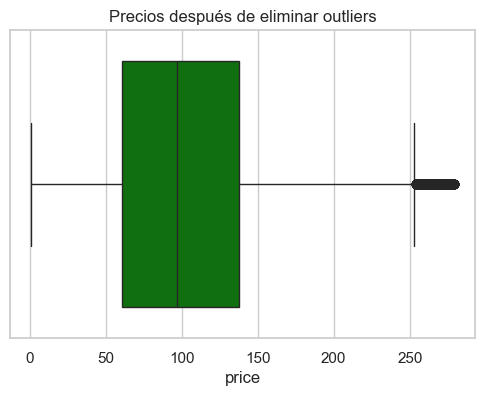

In [13]:
# Boxplot después de limpiar
plt.figure(figsize=(6,4))
sns.boxplot(x=df['price'], color='green')
plt.title("Precios después de eliminar outliers")
plt.show()

In [14]:
# ==============================================================
# 2.2 Fechas
# ==============================================================
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')
df['days_since_last_review'] = (pd.Timestamp.today() - df['last_review']).dt.days

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 18792 entries, 0 to 26003
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              18792 non-null  int64         
 1   name                            18792 non-null  object        
 2   host_id                         18792 non-null  int64         
 3   host_name                       18781 non-null  object        
 4   neighbourhood_group             18792 non-null  object        
 5   neighbourhood                   18792 non-null  object        
 6   latitude                        18792 non-null  float64       
 7   longitude                       18792 non-null  float64       
 8   room_type                       18792 non-null  object        
 9   price                           18792 non-null  float64       
 10  minimum_nights                  18792 non-null  int64         
 11  number_

In [15]:
# ==============================================================
# 2.3 Valores Nulos
# ==============================================================
df['number_of_reviews'] = df['number_of_reviews'].fillna(0)
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df['neighbourhood'] = df['neighbourhood'].fillna('Desconocido')
df['room_type'] = df['room_type'].fillna('Desconocido')
df['host_name'] = df['host_name'].fillna('Sin persona de contacto')
df['license'] = df['license'].fillna('Sin licencia indicada')
                     
# Revisión post-tratamiento
total_filas = len(df)
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / total_filas) * 100

resultado_post = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': porcentaje_nulos.round(2)
}).sort_values(by='Porcentaje (%)', ascending=False)

print("Valores nulos después del tratamiento:\n", resultado_post)

Valores nulos después del tratamiento:
                                 Nulos  Porcentaje (%)
days_since_last_review           2925           15.57
last_review                      2925           15.57
id                                  0            0.00
host_id                             0            0.00
name                                0            0.00
host_name                           0            0.00
neighbourhood_group                 0            0.00
longitude                           0            0.00
room_type                           0            0.00
neighbourhood                       0            0.00
latitude                            0            0.00
minimum_nights                      0            0.00
price                               0            0.00
reviews_per_month                   0            0.00
number_of_reviews                   0            0.00
calculated_host_listings_count      0            0.00
availability_365                    0     

In [16]:
# ==============================================================
# 2.4 Duplicados
# ==============================================================
df = df.drop_duplicates(subset='id')

print("Dimensiones del dataset:", df.shape)

Dimensiones del dataset: (18792, 19)


In [17]:
# ==============================================================
# 2.5 Normalizar texto de variables categóricas
# ==============================================================
df['room_type'] = df['room_type'].str.strip().str.title()
if 'neighbourhood_group' in df.columns:
    df['neighbourhood_group'] = df['neighbourhood_group'].fillna('Sin dato')

In [18]:
df['name'] = df['name'].str.title().str.strip()

print(df['name'].head(10))

0                                  Bright And Airy Room
4          Magic Artistic House In The Center Of Madrid
5                         Tu Hogar En Centro De Madrid.
6      Sunny Attic Duplex Flat With Terrace Next To Sol
8                     Cool Apart. (10Min Center + Wifi)
9     Cozy Attic With Intimate Rooftop Terrace+ Elev...
10                                 *** Malasaña B&B ***
13                   Nice Central Tourism-Business Apto
14                  Room In The Center -La Latina- Wifi
15                     Calm, Affordable Room In Madrid.
Name: name, dtype: object


In [19]:
# ==============================================================
# 2.6 Renombrar columnas
# ==============================================================
df = df.rename(columns={'id': 'ID', 'name': 'Nombre_Alojamiento', 'host_id': 'ID_Anfitrión', 'host_name': 'Nombre_Anfitrión', 'neighbourhood': 'Barrio', 'neighbourhood_group': 'Zona', 'latitude': 'Latitud', 'longitude': 'Longitud', 'room_type': 'Tipo_Habitación', 'price': 'Precio', 'minimum_nights': 'Noches_Mínimas', 'number_of_reviews': 'Número_de_Reseñas', 'last_review': 'Última_Reseña', 'reviews_per_month': 'Reseñas_por_Mes', 'calculated_host_listings_count': 'Alojamientos_del_Anfitrión', 'availability_365': 'Disponibilidad_365_días', 'days_since_last_review': 'Días_desde_última_reseña', 'license': 'Licencia', 'number_of_reviews_ltm': 'Número_de_Reseñas_Últimos_12_meses'})

# 3 Análisis Exploratorio EDA

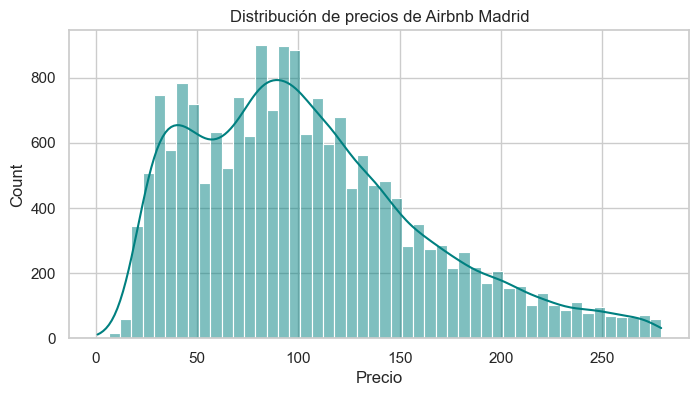

In [20]:
# ==============================================================
# 3.1 Distribución de precios
# ==============================================================
plt.figure(figsize=(8,4))
sns.histplot(df['Precio'], bins=50, kde=True, color='teal')
plt.title("Distribución de precios de Airbnb Madrid")
plt.xlabel("Precio")
plt.show()

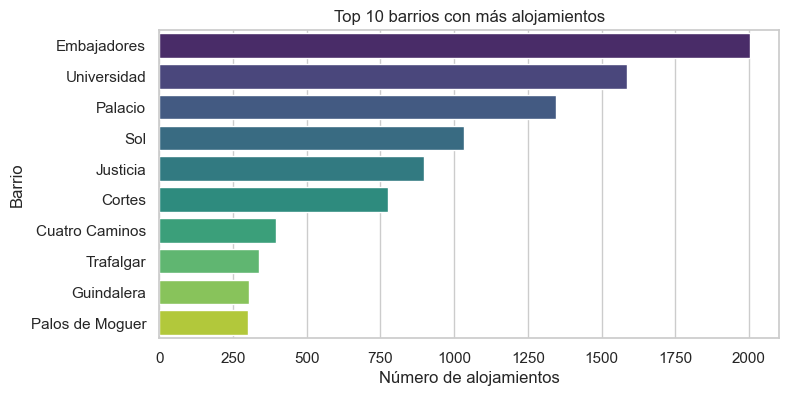

In [21]:
# ==============================================================
# 3.2 Top 10 barrios con más alojamientos
# ==============================================================
top_neighbourhoods = df['Barrio'].value_counts().head(10)

plt.figure(figsize=(8,4))
sns.barplot(
    x=top_neighbourhoods.values,
    y=top_neighbourhoods.index,
    hue=top_neighbourhoods.index,
    palette="viridis",
    dodge=False,                    
    legend=False                   
)
plt.title("Top 10 barrios con más alojamientos")
plt.xlabel("Número de alojamientos")
plt.ylabel("Barrio")
plt.show()

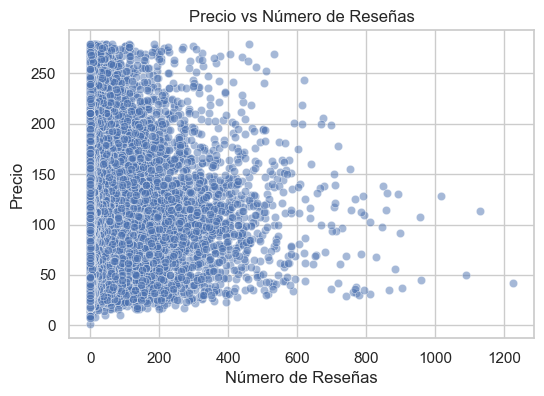

In [22]:
# ==============================================================
# 3.3 Relación precio vs número de reviews
# ==============================================================
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='Número_de_Reseñas', y='Precio', alpha=0.5)
plt.title("Precio vs Número de Reseñas")
plt.xlabel("Número de Reseñas")
plt.ylabel("Precio")
plt.show()

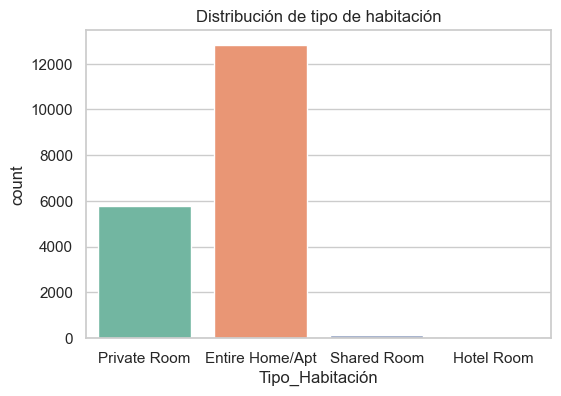

In [23]:
# ==============================================================
# 3.4 Distribución del tipo de habitación
# ==============================================================
plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x='Tipo_Habitación',
    hue=df['Tipo_Habitación'],  
    palette="Set2",
    dodge=False,
    legend=False
)
plt.title("Distribución de tipo de habitación")
plt.show()

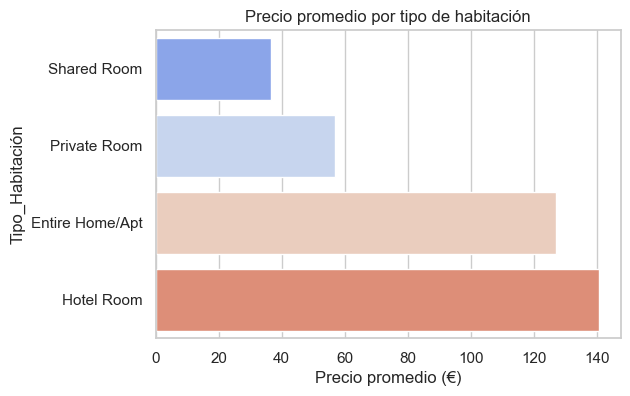

In [24]:
# ==============================================================
# 3.5  Precio promedio por tipo de habitación
# ==============================================================
avg_price_room = df.groupby('Tipo_Habitación')['Precio'].mean().sort_values()

plt.figure(figsize=(6,4))
sns.barplot(
    x=avg_price_room.values,
    y=avg_price_room.index,
    hue=avg_price_room.index, 
    palette="coolwarm",
    dodge=False,
    legend=False
)
plt.title("Precio promedio por tipo de habitación")
plt.xlabel("Precio promedio (€)")
plt.show()

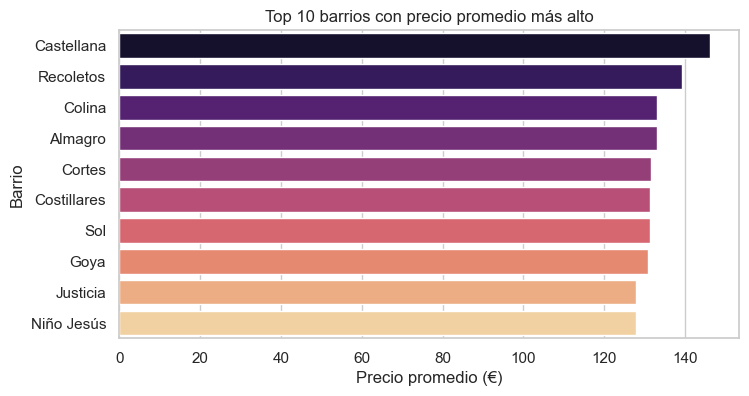

In [25]:
# ==============================================================
# 3.6  Precio promedio por barrio (Top 10)
# ==============================================================
avg_price_neigh = df.groupby('Barrio')['Precio'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,4))
sns.barplot(
    x=avg_price_neigh.values,
    y=avg_price_neigh.index,
    hue=avg_price_neigh.index,
    palette="magma",
    dodge=False,
    legend=False
)
plt.title("Top 10 barrios con precio promedio más alto")
plt.xlabel("Precio promedio (€)")
plt.ylabel("Barrio")
plt.show()

# 3 Guardar Dataframe limpio

In [26]:
# Ruta de salida del CSV limpio
output_csv = project_dir / "Data" / "listings_limpio.csv"

# Guardar CSV limpio
df.to_csv(
    output_csv,
    index=False,
    sep=";",        # separador de columnas (Power BI en español lo espera)
    decimal=".",    # lat/lon se guardan con punto decimal
    encoding="utf-8-sig"
)

print("CSV guardado en:", output_csv)

CSV guardado en: C:\Users\Maria\Desktop\Proyecto Bootcamp\Repositorio GitHub\Proyecto_Airbnb\Data\listings_limpio.csv
